#### Intelligent Drug Recommendation System using Machine Learning and NLP

The Intelligent Drug Recommendation System is a smart application that helps users find suitable medicines for different health conditions based on patient reviews and ratings. The system studies feedback given by people who have already used various medicines and identifies which drugs worked better for specific diseases or conditions.

It analyzes information such as medicine names, patient experiences, ratings, and comments to recommend the most effective medicines. The system can also show how satisfied patients were with a particular drug and help users compare medicines for the same condition.

The project uses Artificial Intelligence techniques to understand patient reviews automatically and provide better recommendations. An interactive dashboard is also created where users can search for a medical condition and view recommended medicines along with ratings and review insights in an easy-to-understand format.

This system can help people make more informed decisions by learning from real patient experiences and medicine reviews.

The Intelligent Drug Recommendation System is a Machine Learning and Natural Language Processing (NLP) project that recommends suitable medicines based on patient conditions, reviews, and ratings.

- The system analyzes patient feedback, drug effectiveness, sentiment, and ratings to help users identify the most effective medicines for specific medical conditions.

- The project uses the Drugs.com Drug Review Dataset from Kaggle and covers the complete Data Science lifecycle:
    - Data Understanding
    - Data Cleaning
    - Exploratory Data Analysis (EDA)
    - NLP Processing
    - Feature Engineering
    - Machine Learning
    - Model Evaluation
    - Recommendation System
    - Streamlit
    - Deployment

#### Data Importing 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
from warnings import filterwarnings 
filterwarnings('ignore')

#### Data Understanding

In [2]:
df=pd.read_csv(r'drugsComTrain_raw.csv')

In [3]:
df

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37
...,...,...,...,...,...,...,...
161292,191035,Campral,Alcohol Dependence,"""I wrote my first report in Mid-October of 201...",10,31-May-15,125
161293,127085,Metoclopramide,Nausea/Vomiting,"""I was given this in IV before surgey. I immed...",1,1-Nov-11,34
161294,187382,Orencia,Rheumatoid Arthritis,"""Limited improvement after 4 months, developed...",2,15-Mar-14,35
161295,47128,Thyroid desiccated,Underactive Thyroid,"""I&#039;ve been on thyroid medication 49 years...",10,19-Sep-15,79


In [4]:
test=pd.read_csv(r'drugsComTest_raw.csv')

In [5]:
test

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,163740,Mirtazapine,Depression,"""I&#039;ve tried a few antidepressants over th...",10,28-Feb-12,22
1,206473,Mesalamine,"Crohn's Disease, Maintenance","""My son has Crohn&#039;s disease and has done ...",8,17-May-09,17
2,159672,Bactrim,Urinary Tract Infection,"""Quick reduction of symptoms""",9,29-Sep-17,3
3,39293,Contrave,Weight Loss,"""Contrave combines drugs that were used for al...",9,5-Mar-17,35
4,97768,Cyclafem 1 / 35,Birth Control,"""I have been on this birth control for one cyc...",9,22-Oct-15,4
...,...,...,...,...,...,...,...
53761,159999,Tamoxifen,"Breast Cancer, Prevention","""I have taken Tamoxifen for 5 years. Side effe...",10,13-Sep-14,43
53762,140714,Escitalopram,Anxiety,"""I&#039;ve been taking Lexapro (escitaploprgra...",9,8-Oct-16,11
53763,130945,Levonorgestrel,Birth Control,"""I&#039;m married, 34 years old and I have no ...",8,15-Nov-10,7
53764,47656,Tapentadol,Pain,"""I was prescribed Nucynta for severe neck/shou...",1,28-Nov-11,20


#### Data Understanding

In [6]:
df.shape

(161297, 7)

In [7]:
df.columns

Index(['uniqueID', 'drugName', 'condition', 'review', 'rating', 'date',
       'usefulCount'],
      dtype='str')

In [8]:
df.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37


In [9]:
df.tail()

,uniqueID,drugName,condition,review,rating,date,usefulCount
161292,191035,Campral,Alcohol Dependence,"""I wrote my first report in Mid-October of 201...",10,31-May-15,125
161293,127085,Metoclopramide,Nausea/Vomiting,"""I was given this in IV before surgey. I immed...",1,1-Nov-11,34
161294,187382,Orencia,Rheumatoid Arthritis,"""Limited improvement after 4 months, developed...",2,15-Mar-14,35
161295,47128,Thyroid desiccated,Underactive Thyroid,"""I&#039;ve been on thyroid medication 49 years...",10,19-Sep-15,79
161296,215220,Lubiprostone,"Constipation, Chronic","""I&#039;ve had chronic constipation all my adu...",9,13-Dec-14,116


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 161297 entries, 0 to 161296
Data columns (total 7 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   uniqueID     161297 non-null  int64
 1   drugName     161297 non-null  str  
 2   condition    160398 non-null  str  
 3   review       161297 non-null  str  
 4   rating       161297 non-null  int64
 5   date         161297 non-null  str  
 6   usefulCount  161297 non-null  int64
dtypes: int64(3), str(4)
memory usage: 84.6 MB


#### Data Cleaning

In [11]:
df.head()

,uniqueID,drugName,condition,review,rating,date,usefulCount
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,20-May-12,27
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,27-Apr-10,192
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,14-Dec-09,17
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,3-Nov-15,10
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,27-Nov-16,37


In [12]:
df.dtypes

uniqueID       int64
drugName         str
condition        str
review           str
rating         int64
date             str
usefulCount    int64
dtype: object

In [13]:
df['date']=pd.to_datetime(df['date'])

In [14]:
df['drugName']=df['drugName'].astype('object')

In [15]:
df['condition']=df['condition'].astype('object')

In [16]:
df['review']=df['review'].astype('object')

In [17]:
df.dtypes

uniqueID                int64
drugName               object
condition              object
review                 object
rating                  int64
date           datetime64[us]
usefulCount             int64
dtype: object

In [18]:
df.isnull().sum()

uniqueID         0
drugName         0
condition      899
review           0
rating           0
date             0
usefulCount      0
dtype: int64

In [19]:
df['condition'] = df.groupby('drugName')['condition'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else 'Unknown')
)

In [20]:
df.isnull().sum()

uniqueID       0
drugName       0
condition      0
review         0
rating         0
date           0
usefulCount    0
dtype: int64

In [21]:
df.duplicated().sum()

0

In [22]:
df['rating'].describe()

count    161297.000000
mean          6.994377
std           3.272329
min           1.000000
25%           5.000000
50%           8.000000
75%          10.000000
max          10.000000
Name: rating, dtype: float64

#### EDA 

##### Univariate Analysis

###### Rating Distribution

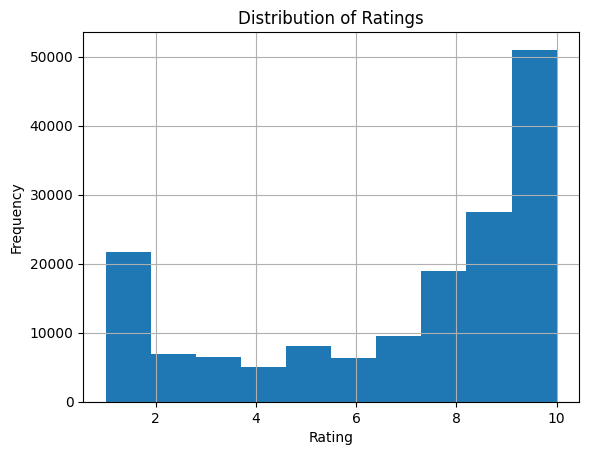

In [23]:
import matplotlib.pyplot as plt

df['rating'].hist(bins=10)
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.title('Distribution of Ratings')
plt.show()

- Observation
    - Most ratings are concentrated between 8 to 10
    - Very few low ratings
- Business Understanding
    - Majority of drugs receive good feedback
    - Positive sentiment dominates the dataset

###### Useful Count Distribution

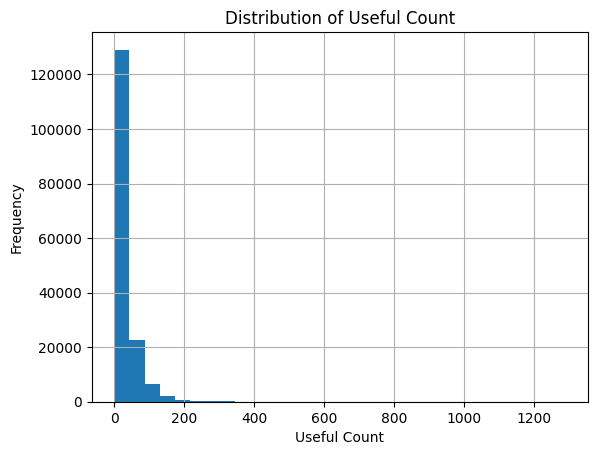

In [24]:
df['usefulCount'].hist(bins=30)
plt.xlabel('Useful Count')
plt.ylabel('Frequency')
plt.title('Distribution of Useful Count')
plt.show()

- Insights
    - Majority of reviews have low useful counts.
    - Only a small percentage of reviews are highly helpful.
    - Some reviews receive exceptionally high engagement.
- Observation
    - Most reviews have low useful counts
    - Few reviews have extremely high useful counts (outliers)
- Business Understanding
    - Only a few reviews are considered highly valuable by users
    - Popular or detailed reviews gain more engagement

###### Boxplot for Outliers

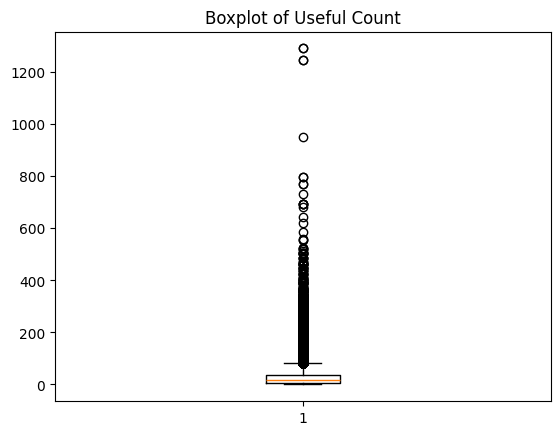

In [25]:
plt.boxplot(df['usefulCount'])
plt.title('Boxplot of Useful Count')
plt.show()

###### Statistical Summary

In [26]:
df[['rating','usefulCount']].describe()

,rating,usefulCount
count,161297.000000,161297.000000
mean,6.994377,28.004755
std,3.272329,36.403742
min,1.000000,0.000000
25%,5.000000,6.000000
50%,8.000000,16.000000
75%,10.000000,36.000000
max,10.000000,1291.000000


###### Top Conditions

In [27]:
df['condition'].value_counts().head(10)

condition
Birth Control      29183
Depression          9115
Pain                6180
Anxiety             5935
Acne                5598
Bipolar Disorde     4257
Insomnia            3683
Weight Loss         3614
Obesity             3583
ADHD                3402
Name: count, dtype: int64

Observation
- Top conditions:
    - Birth Control
    - Depression
    - Pain
    - Anxiety
    - Acne
- Insights
    -These conditions have the highest patient discussions and medicine usage, making them high-priority areas for intelligent recommendation systems.    ms.

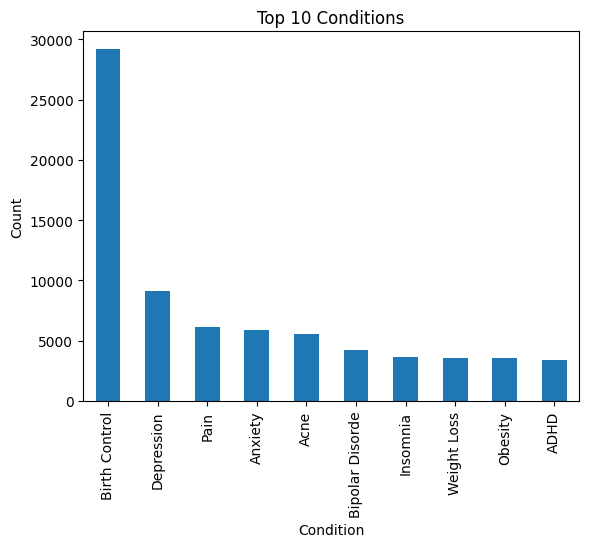

In [28]:
df['condition'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Conditions')
plt.xlabel('Condition')
plt.ylabel('Count')
plt.show()

###### Most Reviewed Drugs

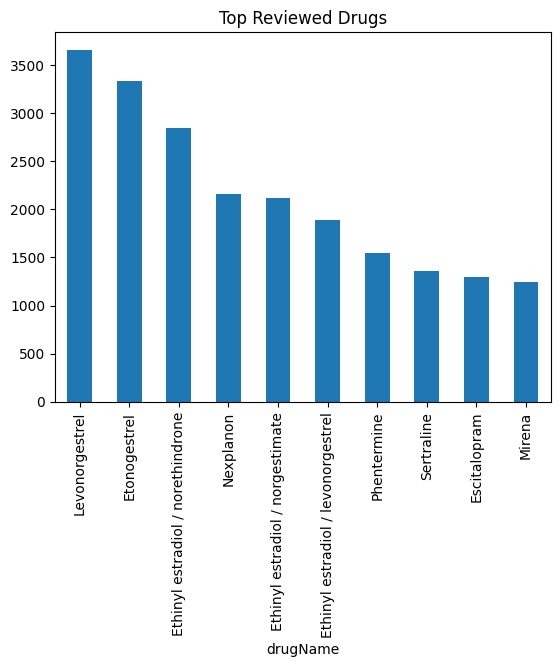

In [29]:
df['drugName'].value_counts().head(10).plot(kind='bar')
plt.title('Top Reviewed Drugs')
plt.show()

Observation
- Certain drugs dominate review counts:
    - Levonorgestrel
    - Etonogestrel
    - Nexplanon etc.
- Business Insights
    - Frequently reviewed drugs are more widely used/popular.
    - Drug popularity becomes a valuable feature.
    - Popular drugs may have more reliable feedback.

###### Text Feature Analysis

In [30]:
df['review_length'] = df['review'].apply(len)

In [31]:
df.head(10)

,uniqueID,drugName,condition,review,rating,date,usefulCount,review_length
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,2012-05-20,27,79
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,2010-04-27,192,741
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,2009-12-14,17,755
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,2015-11-03,10,448
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,2016-11-27,37,719
5,155963,Cialis,Benign Prostatic Hyperplasia,"""2nd day on 5mg started to work with rock hard...",2,2015-11-28,43,403
6,165907,Levonorgestrel,Emergency Contraception,"""He pulled out, but he cummed a bit in me. I t...",1,2017-03-07,5,142
7,102654,Aripiprazole,Bipolar Disorde,"""Abilify changed my life. There is hope. I was...",10,2015-03-14,32,733
8,74811,Keppra,Epilepsy,""" I Ve had nothing but problems with the Kepp...",1,2016-08-09,11,193
9,48928,Ethinyl estradiol / levonorgestrel,Birth Control,"""I had been on the pill for many years. When m...",8,2016-12-08,1,737


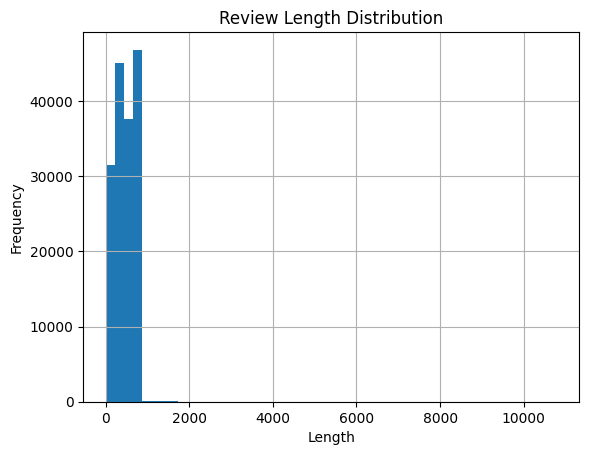

In [32]:
df['review_length'].hist(bins=50)
plt.title('Review Length Distribution')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.show()

- Insights
    - Most reviews are short-to-medium length.
    - Very long reviews are rare.
    - Longer reviews often contain more detailed patient experiences.
- Observation
    - Most reviews are short-medium length.
    - Few extremely long reviews exist.
- Business Understanding
    - Detailed reviews may contain richer information.

#### Bivariate Analysis

###### Rating vs UsefulCount

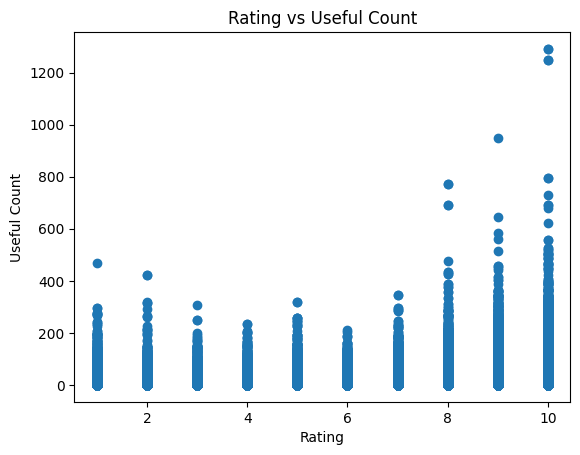

In [33]:
plt.scatter(df['rating'], df['usefulCount'])
plt.xlabel('Rating')
plt.ylabel('Useful Count')
plt.title('Rating vs Useful Count')
plt.show()

- Observation:
 Higher ratings tend to receive more useful counts.
- Business Insights:
 Positive experiences attract more engagement.

##### Condition vs Rating

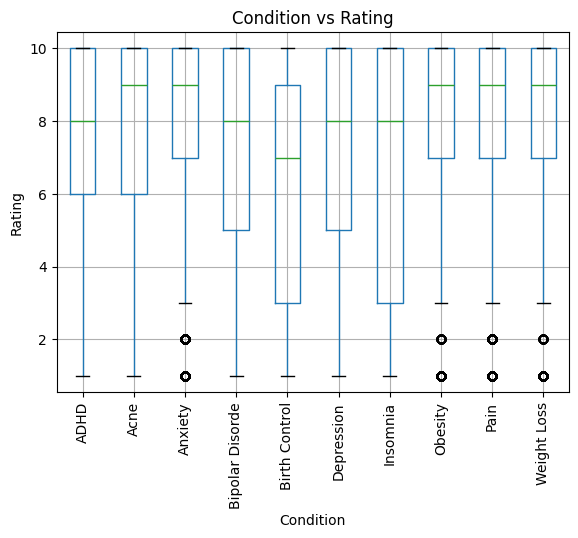

In [34]:
top_conditions = df['condition'].value_counts().head(10).index

filtered_df = df[df['condition'].isin(top_conditions)]

filtered_df.boxplot(column='rating', by='condition', rot=90)

plt.title('Condition vs Rating')
plt.suptitle('')
plt.xlabel('Condition')
plt.ylabel('Rating')
plt.show()

Insights
- Ratings vary significantly across medical conditions.
- Some conditions consistently receive higher satisfaction scores.

###### DrugName vs UsefulCount

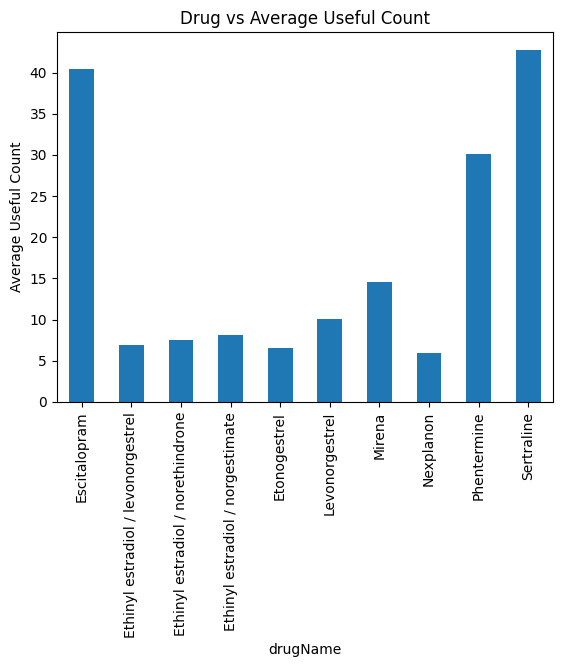

In [35]:
top_drugs = df['drugName'].value_counts().head(10).index

filtered_df = df[df['drugName'].isin(top_drugs)]

filtered_df.groupby('drugName')['usefulCount'].mean().plot(kind='bar')

plt.title('Drug vs Average Useful Count')
plt.ylabel('Average Useful Count')
plt.show()

Insights
- Some drugs consistently receive more useful reviews.
- Popular and effective medicines generate higher engagement.

###### Review Length vs Rating

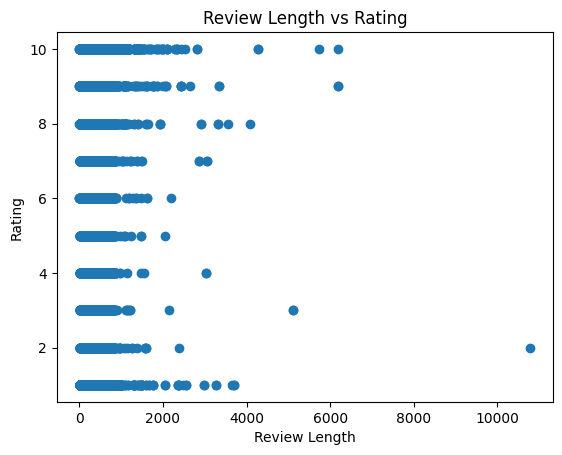

In [36]:
plt.scatter(df['review_length'], df['rating'])
plt.xlabel('Review Length')
plt.ylabel('Rating')
plt.title('Review Length vs Rating')
plt.show()

Insights
- No strong linear relationship exists.
- Extreme ratings sometimes contain longer reviews.

###### Reviews Per Year

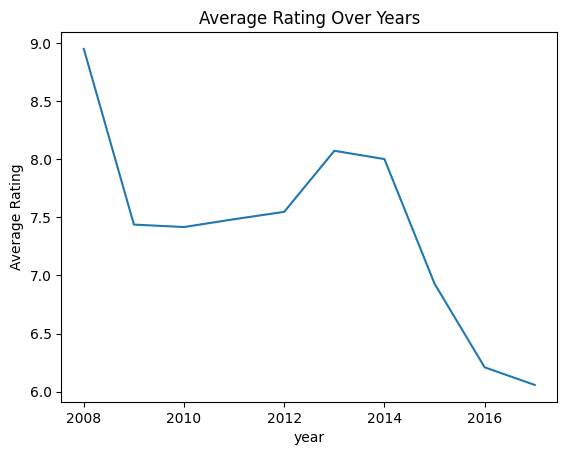

In [37]:
df['year'] = df['date'].dt.year

df.groupby('year')['rating'].mean().plot(kind='line')

plt.title('Average Rating Over Years')
plt.ylabel('Average Rating')
plt.show()

Insights
- Average ratings fluctuate over years.
- Ratings slightly decreased after certain years.
Business Insight :
Patient expectations and treatment experiences evolve over time, indicating the importance of continuously updating recommendation systems.


##### Multivariate Analysis

In [38]:
numerical_df = df[['rating','usefulCount','review_length']]

In [39]:
numerical_df 

,rating,usefulCount,review_length
0,9,27,79
1,8,192,741
2,5,17,755
3,8,10,448
4,9,37,719
...,...,...,...
161292,10,125,689
161293,1,34,262
161294,2,35,95
161295,10,79,772


In [40]:
corr_matrix = numerical_df.corr()
corr_matrix

,rating,usefulCount,review_length
rating,1.000000,0.234185,0.020638
usefulCount,0.234185,1.000000,0.024616
review_length,0.020638,0.024616,1.000000


Insights
- Moderate correlation between:
    - rating ↔ usefulCount
- Weak correlation between:
    - review_length ↔ rating
      
Business Insight
- Review usefulness is influenced more by patient satisfaction than by review size alone.

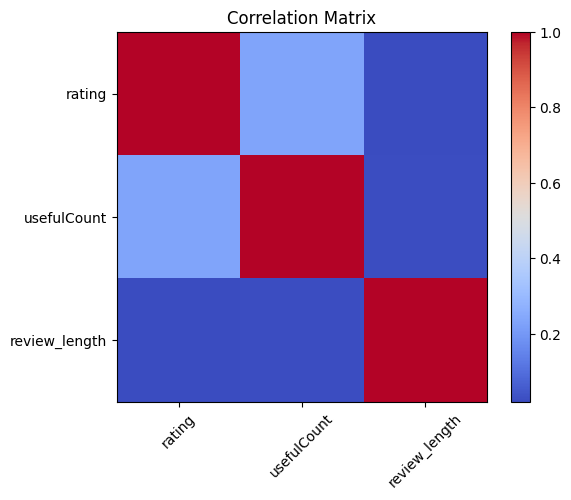

In [41]:
plt.imshow(corr_matrix, cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title('Correlation Matrix')
plt.show()

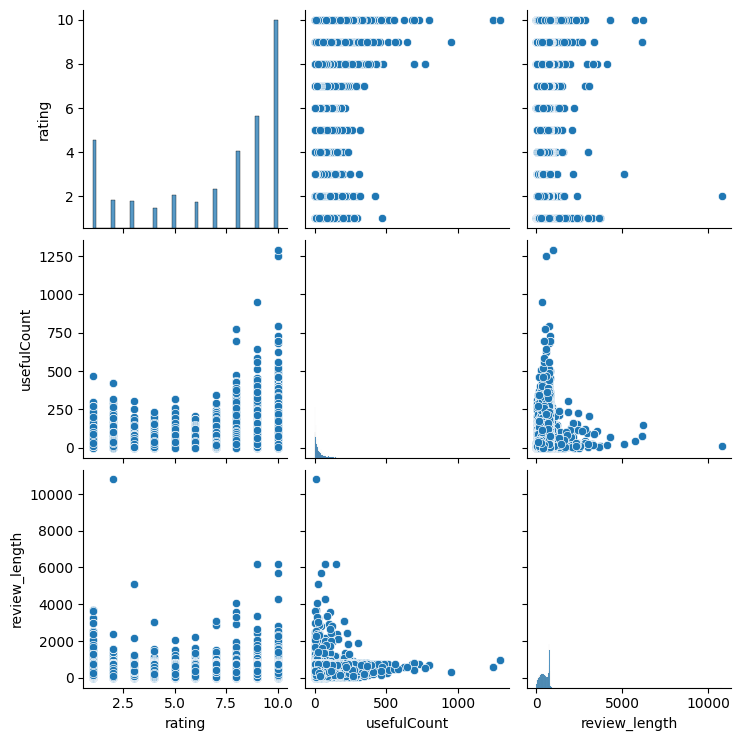

In [42]:
sns.pairplot(df[['rating','usefulCount','review_length']])
plt.show()

###### Condition + Rating + UsefulCount

In [43]:
top_conditions = df['condition'].value_counts().head(5).index
filtered_df = df[df['condition'].isin(top_conditions)]
pivot_table = filtered_df.pivot_table(
    values='usefulCount',
    index='condition',
    columns='rating',
    aggfunc='mean'
)
pivot_table

rating,1,2,3,4,5,6,7,8,9,10
condition,,,,,,,,,,
Acne,7.502773,8.462617,8.774468,7.787234,7.883333,9.377880,11.655488,15.148545,18.106635,22.130459
Anxiety,24.028419,24.290000,24.102740,22.378151,25.010471,29.041176,37.566667,48.962779,55.867188,66.263986
Birth Control,5.901215,6.010466,6.518302,5.803429,5.383326,6.294649,6.084395,7.378505,9.588315,11.353513
Depression,25.224272,29.391421,24.720930,26.164794,26.429929,29.157175,36.602392,50.575441,60.452968,74.077559
Pain,22.572165,18.580460,21.940120,21.616667,29.275862,24.610526,29.786096,38.559742,38.785118,41.316855


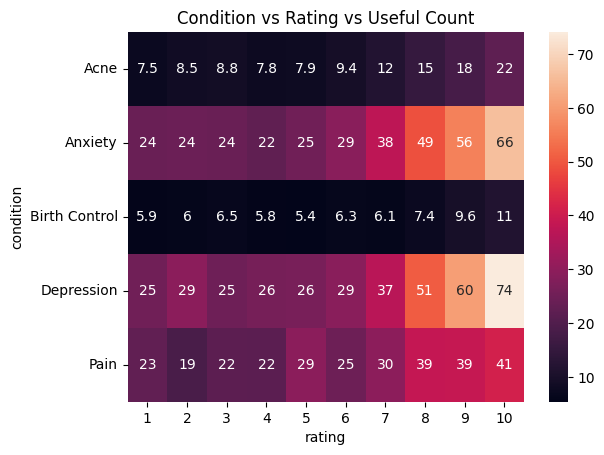

In [44]:
sns.heatmap(pivot_table, annot=True)
plt.title('Condition vs Rating vs Useful Count')
plt.show()

Insights
- Higher ratings generally correspond to higher useful counts.
- Certain conditions consistently show stronger engagement.

Business Insight
- Patients trust highly rated medicines more, making rating and usefulness critical components of recommendation scoring.

###### Year + Rating + UsefulCount

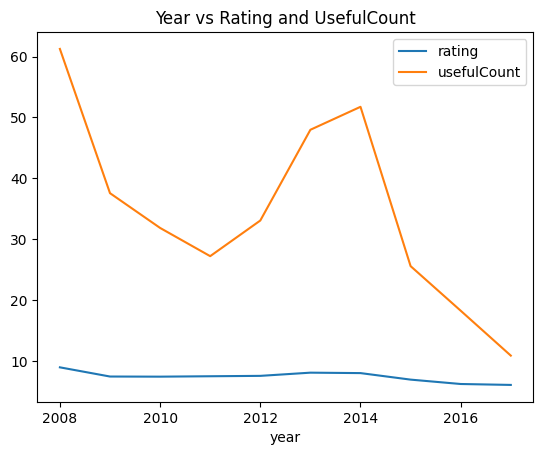

In [45]:
multi_analysis = df.groupby('year')[['rating','usefulCount']].mean()
multi_analysis.plot()
plt.title('Year vs Rating and UsefulCount')
plt.show()

#### Feature Engineering

##### Word Count

In [46]:
df['word_count'] = df['review'].apply(lambda x: len(str(x).split()))

In [47]:
df

,uniqueID,drugName,condition,review,rating,date,usefulCount,review_length,year,word_count
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,2012-05-20,27,79,2012,17
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,2010-04-27,192,741,2010,141
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,2009-12-14,17,755,2009,134
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,2015-11-03,10,448,2015,89
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,2016-11-27,37,719,2016,124
...,...,...,...,...,...,...,...,...,...,...
161292,191035,Campral,Alcohol Dependence,"""I wrote my first report in Mid-October of 201...",10,2015-05-31,125,689,2015,127
161293,127085,Metoclopramide,Nausea/Vomiting,"""I was given this in IV before surgey. I immed...",1,2011-11-01,34,262,2011,50
161294,187382,Orencia,Rheumatoid Arthritis,"""Limited improvement after 4 months, developed...",2,2014-03-15,35,95,2014,14
161295,47128,Thyroid desiccated,Underactive Thyroid,"""I&#039;ve been on thyroid medication 49 years...",10,2015-09-19,79,772,2015,136


##### Character Count

In [48]:
df['char_count'] = df['review'].apply(len)

##### Sentence Count

In [49]:
df['sentence_count'] = df['review'].apply(
    lambda x: len(str(x).split('.'))
)

In [50]:
df

,uniqueID,drugName,condition,review,rating,date,usefulCount,review_length,year,word_count,char_count,sentence_count
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,2012-05-20,27,79,2012,17,79,1
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,2010-04-27,192,741,2010,141,741,12
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,2009-12-14,17,755,2009,134,755,12
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,2015-11-03,10,448,2015,89,448,5
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,2016-11-27,37,719,2016,124,719,12
...,...,...,...,...,...,...,...,...,...,...,...,...
161292,191035,Campral,Alcohol Dependence,"""I wrote my first report in Mid-October of 201...",10,2015-05-31,125,689,2015,127,689,9
161293,127085,Metoclopramide,Nausea/Vomiting,"""I was given this in IV before surgey. I immed...",1,2011-11-01,34,262,2011,50,262,6
161294,187382,Orencia,Rheumatoid Arthritis,"""Limited improvement after 4 months, developed...",2,2014-03-15,35,95,2014,14,95,2
161295,47128,Thyroid desiccated,Underactive Thyroid,"""I&#039;ve been on thyroid medication 49 years...",10,2015-09-19,79,772,2015,136,772,11


##### Extract Year

In [51]:
df['year'] = df['date'].dt.year

##### Extract Month

In [52]:
df['month'] = df['date'].dt.month

##### Extract Day

In [53]:
df['day'] = df['date'].dt.day

##### Extract Day Name

In [54]:
df['day_name'] = df['date'].dt.day_name()

In [55]:
df

,uniqueID,drugName,condition,review,rating,date,usefulCount,review_length,year,word_count,char_count,sentence_count,month,day,day_name
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,2012-05-20,27,79,2012,17,79,1,5,20,Sunday
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,2010-04-27,192,741,2010,141,741,12,4,27,Tuesday
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,2009-12-14,17,755,2009,134,755,12,12,14,Monday
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,2015-11-03,10,448,2015,89,448,5,11,3,Tuesday
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,2016-11-27,37,719,2016,124,719,12,11,27,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161292,191035,Campral,Alcohol Dependence,"""I wrote my first report in Mid-October of 201...",10,2015-05-31,125,689,2015,127,689,9,5,31,Sunday
161293,127085,Metoclopramide,Nausea/Vomiting,"""I was given this in IV before surgey. I immed...",1,2011-11-01,34,262,2011,50,262,6,11,1,Tuesday
161294,187382,Orencia,Rheumatoid Arthritis,"""Limited improvement after 4 months, developed...",2,2014-03-15,35,95,2014,14,95,2,3,15,Saturday
161295,47128,Thyroid desiccated,Underactive Thyroid,"""I&#039;ve been on thyroid medication 49 years...",10,2015-09-19,79,772,2015,136,772,11,9,19,Saturday


##### Sentiment Feature

In [56]:
pip install textblob

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [57]:
from textblob import TextBlob

In [ ]:
df['sentiment'] = df['review'].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)

In [ ]:
df

-1 → Negative,
0  → Neutral,
+1 → Positive

Insights
- Positive reviews dominate the dataset.
- Sentiment scores align strongly with ratings.

Business Insight
- Sentiment analysis helps automatically understand patient satisfaction and improves intelligent medicine recommendation.

##### Useful Review Feature

In [60]:
df['is_useful'] = df['usefulCount'].apply(
    lambda x: 1 if x > 10 else 0
) 

In [61]:
df['is_useful'].unique()

array([1, 0], dtype=int64)

In [62]:
df['is_useful'].nunique()

2

##### Drug Popularity Feature

In [63]:
drug_counts = df['drugName'].value_counts()
drug_counts 

drugName
Levonorgestrel                       3657
Etonogestrel                         3336
Ethinyl estradiol / norethindrone    2850
Nexplanon                            2156
Ethinyl estradiol / norgestimate     2117
                                     ... 
Oxytocin                                1
Iluvien                                 1
Mavik                                   1
Aldomet                                 1
Grifulvin V                             1
Name: count, Length: 3436, dtype: int64

In [64]:
df['drug_popularity'] = df['drugName'].map(drug_counts)

In [65]:
df

,uniqueID,drugName,condition,review,rating,date,usefulCount,review_length,year,word_count,char_count,sentence_count,month,day,day_name,sentiment,is_useful,drug_popularity
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,2012-05-20,27,79,2012,17,79,1,5,20,Sunday,0.000000,1,69
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,2010-04-27,192,741,2010,141,741,12,4,27,Tuesday,0.168333,1,127
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,2009-12-14,17,755,2009,134,755,12,12,14,Monday,0.067210,1,10
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,2015-11-03,10,448,2015,89,448,5,11,3,Tuesday,0.179545,0,219
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,2016-11-27,37,719,2016,124,719,12,11,27,Sunday,0.194444,1,437
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161292,191035,Campral,Alcohol Dependence,"""I wrote my first report in Mid-October of 201...",10,2015-05-31,125,689,2015,127,689,9,5,31,Sunday,0.262917,1,91
161293,127085,Metoclopramide,Nausea/Vomiting,"""I was given this in IV before surgey. I immed...",1,2011-11-01,34,262,2011,50,262,6,11,1,Tuesday,-0.276389,1,143
161294,187382,Orencia,Rheumatoid Arthritis,"""Limited improvement after 4 months, developed...",2,2014-03-15,35,95,2014,14,95,2,3,15,Saturday,-0.223810,1,21
161295,47128,Thyroid desiccated,Underactive Thyroid,"""I&#039;ve been on thyroid medication 49 years...",10,2015-09-19,79,772,2015,136,772,11,9,19,Saturday,0.212597,1,159


Insights
- Certain drugs dominate review frequency.
- Popular medicines have stronger review reliability.
    
Business Insight:
 - Drug popularity acts as a trust indicator because highly reviewed medicines have broader patient validation.

##### Condition Frequency Feature

In [66]:
condition_counts = df['condition'].value_counts()
condition_counts

condition
Birth Control                                  29183
Depression                                      9115
Pain                                            6180
Anxiety                                         5935
Acne                                            5598
                                               ...  
Tinea Barbae                                       1
Acute Nonlymphocytic Leukemia                      1
62</span> users found this comment helpful.        1
92</span> users found this comment helpful.        1
Neutropenia                                        1
Name: count, Length: 885, dtype: int64

In [67]:
df['condition_frequency'] = df['condition'].map(condition_counts)

In [68]:
df

,uniqueID,drugName,condition,review,rating,date,usefulCount,review_length,year,word_count,char_count,sentence_count,month,day,day_name,sentiment,is_useful,drug_popularity,condition_frequency
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,2012-05-20,27,79,2012,17,79,1,5,20,Sunday,0.000000,1,69,19
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,2010-04-27,192,741,2010,141,741,12,4,27,Tuesday,0.168333,1,127,3402
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,2009-12-14,17,755,2009,134,755,12,12,14,Monday,0.067210,1,10,29183
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,2015-11-03,10,448,2015,89,448,5,11,3,Tuesday,0.179545,0,219,29183
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,2016-11-27,37,719,2016,124,719,12,11,27,Sunday,0.194444,1,437,1084
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161292,191035,Campral,Alcohol Dependence,"""I wrote my first report in Mid-October of 201...",10,2015-05-31,125,689,2015,127,689,9,5,31,Sunday,0.262917,1,91,389
161293,127085,Metoclopramide,Nausea/Vomiting,"""I was given this in IV before surgey. I immed...",1,2011-11-01,34,262,2011,50,262,6,11,1,Tuesday,-0.276389,1,143,749
161294,187382,Orencia,Rheumatoid Arthritis,"""Limited improvement after 4 months, developed...",2,2014-03-15,35,95,2014,14,95,2,3,15,Saturday,-0.223810,1,21,995
161295,47128,Thyroid desiccated,Underactive Thyroid,"""I&#039;ve been on thyroid medication 49 years...",10,2015-09-19,79,772,2015,136,772,11,9,19,Saturday,0.212597,1,159,451


Insights
- Some conditions are extremely common.
- Many rare conditions have very limited reviews.

Business Insight:
- Recommendation systems perform more reliably for common conditions due to richer review data availability.

###### Rating catagory

In [69]:
def rating_category(rating):
    if rating >= 7:
        return 'Positive'
    elif rating >= 4:
        return 'Neutral'
    else:
        return 'Negative'


In [70]:
df['rating_category'] = df['rating'].apply(rating_category)

In [71]:
df

,uniqueID,drugName,condition,review,rating,date,usefulCount,review_length,year,word_count,char_count,sentence_count,month,day,day_name,sentiment,is_useful,drug_popularity,condition_frequency,rating_category
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,2012-05-20,27,79,2012,17,79,1,5,20,Sunday,0.000000,1,69,19,Positive
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,2010-04-27,192,741,2010,141,741,12,4,27,Tuesday,0.168333,1,127,3402,Positive
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,2009-12-14,17,755,2009,134,755,12,12,14,Monday,0.067210,1,10,29183,Neutral
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,2015-11-03,10,448,2015,89,448,5,11,3,Tuesday,0.179545,0,219,29183,Positive
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,2016-11-27,37,719,2016,124,719,12,11,27,Sunday,0.194444,1,437,1084,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161292,191035,Campral,Alcohol Dependence,"""I wrote my first report in Mid-October of 201...",10,2015-05-31,125,689,2015,127,689,9,5,31,Sunday,0.262917,1,91,389,Positive
161293,127085,Metoclopramide,Nausea/Vomiting,"""I was given this in IV before surgey. I immed...",1,2011-11-01,34,262,2011,50,262,6,11,1,Tuesday,-0.276389,1,143,749,Negative
161294,187382,Orencia,Rheumatoid Arthritis,"""Limited improvement after 4 months, developed...",2,2014-03-15,35,95,2014,14,95,2,3,15,Saturday,-0.223810,1,21,995,Negative
161295,47128,Thyroid desiccated,Underactive Thyroid,"""I&#039;ve been on thyroid medication 49 years...",10,2015-09-19,79,772,2015,136,772,11,9,19,Saturday,0.212597,1,159,451,Positive


##### Average Rating Per Drug

In [72]:
avg_rating = avg_rating = df.groupby('drugName')['rating'].mean()
avg_rating

drugName
A + D Cracked Skin Relief               10.000000
A / B Otic                              10.000000
Abacavir / dolutegravir / lamivudine     8.211538
Abacavir / lamivudine / zidovudine       9.000000
Abatacept                                7.157895
                                          ...    
Zyvox                                    9.000000
ZzzQuil                                  2.500000
depo-subQ provera 104                    1.000000
ella                                     6.980392
femhrt                                   4.000000
Name: rating, Length: 3436, dtype: float64

In [73]:
df['avg_drug_rating'] = df['drugName'].map(avg_rating)

NLP Cleaning

##### Before vectorization:

In [74]:
import re

In [75]:
def clean_review(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text
df['clean_review'] = df['review'].apply(clean_review)

In [76]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\kaush\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [77]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

df['clean_review'] = df['clean_review'].apply(
    lambda x: ' '.join(
        word for word in x.split()
        if word not in stop_words
    )
)

In [78]:
df

,uniqueID,drugName,condition,review,rating,date,usefulCount,review_length,year,word_count,...,month,day,day_name,sentiment,is_useful,drug_popularity,condition_frequency,rating_category,avg_drug_rating,clean_review
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,2012-05-20,27,79,2012,17,...,5,20,Sunday,0.000000,1,69,19,Positive,5.942029,side effect take combination bystolic mg fish oil
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,2010-04-27,192,741,2010,141,...,4,27,Tuesday,0.168333,1,127,3402,Positive,5.976378,son halfway fourth week intuniv became concern...
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,2009-12-14,17,755,2009,134,...,12,14,Monday,0.067210,1,10,29183,Neutral,7.600000,used take another oral contraceptive pill cycl...
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,2015-11-03,10,448,2015,89,...,11,3,Tuesday,0.179545,0,219,29183,Positive,7.470320,first time using form birth control im glad we...
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,2016-11-27,37,719,2016,124,...,11,27,Sunday,0.194444,1,437,1084,Positive,8.647597,suboxone completely turned life around feel he...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161292,191035,Campral,Alcohol Dependence,"""I wrote my first report in Mid-October of 201...",10,2015-05-31,125,689,2015,127,...,5,31,Sunday,0.262917,1,91,389,Positive,9.252747,wrote first report midoctober alcohol since po...
161293,127085,Metoclopramide,Nausea/Vomiting,"""I was given this in IV before surgey. I immed...",1,2011-11-01,34,262,2011,50,...,11,1,Tuesday,-0.276389,1,143,749,Negative,4.832168,given iv surgey immediately became anxious cou...
161294,187382,Orencia,Rheumatoid Arthritis,"""Limited improvement after 4 months, developed...",2,2014-03-15,35,95,2014,14,...,3,15,Saturday,-0.223810,1,21,995,Negative,6.714286,limited improvement months developed bad rash ...
161295,47128,Thyroid desiccated,Underactive Thyroid,"""I&#039;ve been on thyroid medication 49 years...",10,2015-09-19,79,772,2015,136,...,9,19,Saturday,0.212597,1,159,451,Positive,7.742138,ive thyroid medication years spent first synth...


#### Text Vectorization / Text Preprocessing for ML

In [79]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [80]:
X_text = df['clean_review']

In [81]:
X_numeric = df[[
    'usefulCount',
    'word_count',
    'char_count',
    'sentiment',
    'avg_drug_rating'
]]

In [82]:
df.columns

Index(['uniqueID', 'drugName', 'condition', 'review', 'rating', 'date',
       'usefulCount', 'review_length', 'year', 'word_count', 'char_count',
       'sentence_count', 'month', 'day', 'day_name', 'sentiment', 'is_useful',
       'drug_popularity', 'condition_frequency', 'rating_category',
       'avg_drug_rating', 'clean_review'],
      dtype='str')

In [83]:
df

,uniqueID,drugName,condition,review,rating,date,usefulCount,review_length,year,word_count,...,month,day,day_name,sentiment,is_useful,drug_popularity,condition_frequency,rating_category,avg_drug_rating,clean_review
0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9,2012-05-20,27,79,2012,17,...,5,20,Sunday,0.000000,1,69,19,Positive,5.942029,side effect take combination bystolic mg fish oil
1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8,2010-04-27,192,741,2010,141,...,4,27,Tuesday,0.168333,1,127,3402,Positive,5.976378,son halfway fourth week intuniv became concern...
2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5,2009-12-14,17,755,2009,134,...,12,14,Monday,0.067210,1,10,29183,Neutral,7.600000,used take another oral contraceptive pill cycl...
3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8,2015-11-03,10,448,2015,89,...,11,3,Tuesday,0.179545,0,219,29183,Positive,7.470320,first time using form birth control im glad we...
4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9,2016-11-27,37,719,2016,124,...,11,27,Sunday,0.194444,1,437,1084,Positive,8.647597,suboxone completely turned life around feel he...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161292,191035,Campral,Alcohol Dependence,"""I wrote my first report in Mid-October of 201...",10,2015-05-31,125,689,2015,127,...,5,31,Sunday,0.262917,1,91,389,Positive,9.252747,wrote first report midoctober alcohol since po...
161293,127085,Metoclopramide,Nausea/Vomiting,"""I was given this in IV before surgey. I immed...",1,2011-11-01,34,262,2011,50,...,11,1,Tuesday,-0.276389,1,143,749,Negative,4.832168,given iv surgey immediately became anxious cou...
161294,187382,Orencia,Rheumatoid Arthritis,"""Limited improvement after 4 months, developed...",2,2014-03-15,35,95,2014,14,...,3,15,Saturday,-0.223810,1,21,995,Negative,6.714286,limited improvement months developed bad rash ...
161295,47128,Thyroid desiccated,Underactive Thyroid,"""I&#039;ve been on thyroid medication 49 years...",10,2015-09-19,79,772,2015,136,...,9,19,Saturday,0.212597,1,159,451,Positive,7.742138,ive thyroid medication years spent first synth...


#### Recommendation Engine

##### Grouping Drugs by Condition

In [84]:
recommendation_df = df.groupby(
    ['condition', 'drugName']
).agg({
    'rating':'mean',
    'sentiment':'mean',
    'usefulCount':'mean',
    'drug_popularity':'mean'
}).reset_index()

###### This helps ous to give summarized drug performance

##### Create Ranking Score

In [85]:
recommendation_df['recommendation_score'] = (
    recommendation_df['rating'] * 0.4 +
    recommendation_df['sentiment'] * 2 +
    recommendation_df['usefulCount'] * 0.2 +
    recommendation_df['drug_popularity'] * 0.1
)

###### This is used to combine the rating,sentiment,usefulCount,drug_popularity into one final score

###### Sort Drugs

In [86]:
recommendation_df.sort_values(
    by='recommendation_score',
    ascending=False
).head()

,condition,drugName,rating,sentiment,usefulCount,drug_popularity,recommendation_score
3494,Emergency Contraception,Levonorgestrel,8.472563,0.065231,13.079443,3657.0,371.835376
763,Abnormal Uterine Bleeding,Levonorgestrel,5.322464,-0.002112,14.576087,3657.0,370.739979
1919,Birth Control,Levonorgestrel,7.044084,0.020787,7.784223,3657.0,370.116052
5725,Not Listed / Othe,Levonorgestrel,7.000000,-0.004878,0.200000,3657.0,368.530244
1890,Birth Control,Etonogestrel,5.806248,0.045057,6.583058,3336.0,337.329225


###### Now best medicines come at top.

##### Build Recommendation Function

In [87]:
def recommend_drugs(condition_name):

    filtered = recommendation_df[
        recommendation_df['condition'].str.lower() == condition_name.lower()
    ]

    return filtered.sort_values(
        by='recommendation_score',
        ascending=False
    ).head(5)

In [88]:
recommend_drugs('Depression')

,condition,drugName,rating,sentiment,usefulCount,drug_popularity,recommendation_score
3007,Depression,Sertraline,7.188841,0.070121,50.849785,1360.0,149.185736
2955,Depression,Escitalopram,7.613158,0.095687,45.894737,1292.0,141.615585
2940,Depression,Bupropion,7.364621,0.107131,56.429603,1022.0,116.646030
3018,Depression,Venlafaxine,6.505669,0.050680,31.482993,1016.0,110.600227
2942,Depression,Citalopram,7.567010,0.085536,38.925258,995.0,110.482928


In [89]:
recommend_drugs('Alcohol Dependence')

,condition,drugName,rating,sentiment,usefulCount,drug_popularity,recommendation_score
974,Alcohol Dependence,Revia,9.200000,0.139657,154.200000,6.0,35.399313
972,Alcohol Dependence,Naltrexone,8.500000,0.072657,58.155556,180.0,33.176424
975,Alcohol Dependence,Vivitrol,8.500000,-0.031105,99.750000,54.0,28.687790
968,Alcohol Dependence,Acamprosate,8.899083,0.072229,62.889908,109.0,27.182072
970,Alcohol Dependence,Campral,9.252747,0.115635,68.516484,91.0,26.735666


In [90]:
recommend_drugs('Birth Control')

,condition,drugName,rating,sentiment,usefulCount,drug_popularity,recommendation_score
1919,Birth Control,Levonorgestrel,7.044084,0.020787,7.784223,3657.0,370.116052
1890,Birth Control,Etonogestrel,5.806248,0.045057,6.583058,3336.0,337.329225
1887,Birth Control,Ethinyl estradiol / norethindrone,5.659007,0.020247,7.458350,2850.0,288.795767
1954,Birth Control,Nexplanon,5.679851,0.033527,5.966961,2156.0,219.132387
1888,Birth Control,Ethinyl estradiol / norgestimate,5.954928,0.028928,8.173077,2117.0,215.774442


In [124]:
recommendation_df.to_csv(
    'recommendation_data.csv',
    index=False
)

#### Model Building

In [91]:
X_text = df['clean_review']

In [92]:
X_numeric = df[[
    'rating',
    'sentiment',
    'word_count',
    'char_count',
    'avg_drug_rating',
    'drug_popularity'
]]

In [93]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=10000)

X_text_tfidf = tfidf.fit_transform(X_text)

In [94]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

In [95]:
from scipy.sparse import hstack

X = hstack([X_text_tfidf, X_numeric])

In [96]:
y = df['is_useful']

In [97]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

#### Logistic Regression

In [104]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [105]:
y_pred = model.predict(X_test)

In [106]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.7227216367017979

#### XGBoost

In [107]:
from xgboost import XGBClassifier

In [108]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

In [109]:
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [110]:
y_pred_xgb = xgb_model.predict(X_test)

In [111]:
from sklearn.metrics import accuracy_score,classification_report
print(accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

0.7629882207067576
              precision    recall  f1-score   support

           0       0.77      0.53      0.63     12178
           1       0.76      0.90      0.83     20082

    accuracy                           0.76     32260
   macro avg       0.76      0.72      0.73     32260
weighted avg       0.76      0.76      0.75     32260



SVM

In [125]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
svm_model = LinearSVC(class_weight='balanced')
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

In [126]:
accuracy_score(y_test, y_pred_svm)

0.6443273403595784

In [115]:
params = {
    'C':[0.1,1,10]
}

In [116]:
grid = GridSearchCV(
    LinearSVC(),
    params,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

In [117]:
grid.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=LinearSVC(), n_jobs=-1,
             param_grid={'C': [0.1, 1, 10]}, scoring='accuracy')

In [118]:
best_model = grid.best_estimator_

In [119]:
print(grid.best_params_)

{'C': 0.1}


In [121]:
y_pred = best_model.predict(X_test)

In [122]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.6838189708617483

In [123]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.73      0.26      0.38     12178
           1       0.68      0.94      0.79     20082

    accuracy                           0.68     32260
   macro avg       0.70      0.60      0.58     32260
weighted avg       0.70      0.68      0.63     32260

